In [13]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [14]:
import os
os.chdir('C://Users/manni/Downloads')

datasets = []
for _, _, filenames in os.walk('Daily river levels'):
    datasets.append(filenames)

datasets[0]

import seaborn as sns
import plotly.express as px

for dataset in datasets[0]:
    data = pd.read_csv(f'Daily river levels/{dataset}')

    try:
        data['datetime'] = pd.to_datetime(data['datetime'])
    except:
        data['datetime'] = pd.to_datetime(data['datetime'], format = "%d/%m/%Y")

    df = data[(data['datetime'] >= '2018-01-01') &(data['datetime'] <= '2024-12-31')] # 2018 t0 2024 data
    df = df.reset_index().drop('index', axis = 1)

    display(px.line(df, x='datetime', y='water_level', title=f'Water Level 2018 - 2024 for {dataset}'))

In [15]:
data = pd.read_csv('Daily river levels/dahiti_15354_daily_2025-06-23.csv', parse_dates=['datetime'])
df = data[(data['datetime'] >= '2018-01-01') &(data['datetime'] <= '2024-12-31')] # 2018 t0 2024 data
df = df.reset_index().drop('index', axis = 1)
df

,datetime,water_level
0,2018-12-19,89.465000
1,2018-12-20,89.446222
2,2018-12-21,89.427444
3,2018-12-22,89.408667
4,2018-12-23,89.389889
...,...,...
1805,2023-11-28,89.080222
1806,2023-11-29,89.085667
1807,2023-11-30,89.091111
1808,2023-12-01,89.096556


In [16]:
import plotly.express as px
px.line(data_frame=df, x='datetime', y='water_level', title='Water Level 2018 - 2024')

In [17]:
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day_of_year'] = df['datetime'].dt.dayofyear
df['week_of_year'] = df.day_of_year//7 + 1

df

,datetime,water_level,day,month,year,day_of_year,week_of_year
0,2018-12-19,89.465000,19,12,2018,353,51
1,2018-12-20,89.446222,20,12,2018,354,51
2,2018-12-21,89.427444,21,12,2018,355,51
3,2018-12-22,89.408667,22,12,2018,356,51
4,2018-12-23,89.389889,23,12,2018,357,52
...,...,...,...,...,...,...,...
1805,2023-11-28,89.080222,28,11,2023,332,48
1806,2023-11-29,89.085667,29,11,2023,333,48
1807,2023-11-30,89.091111,30,11,2023,334,48
1808,2023-12-01,89.096556,1,12,2023,335,48


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit_transform(df['water_level'].values.reshape(-1,1)) * 10

array([[3.86474335],
       [3.82956579],
       [3.79438824],
       ...,
       [3.16431456],
       [3.17451398],
       [3.18471338]], shape=(1810, 1))

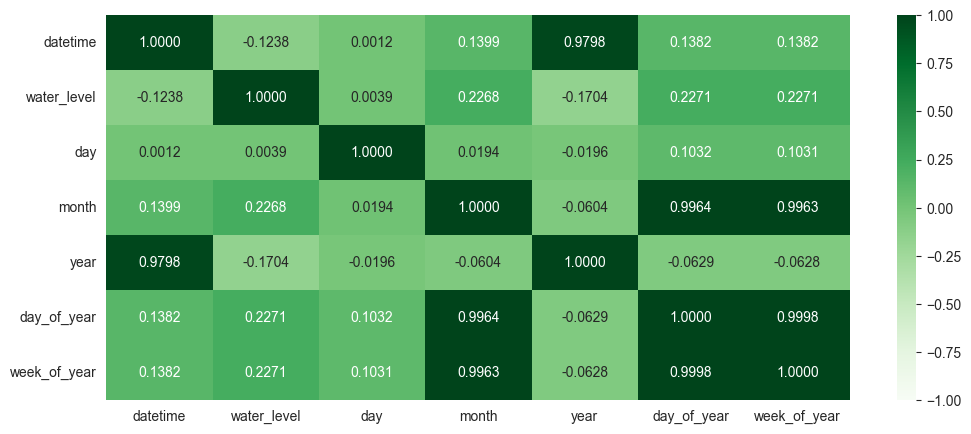

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.heatmap(df.corr(), vmin= -1, annot = True, fmt='.4f', cmap = 'Greens')

plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
X = df.drop(['datetime', 'day_of_year', 'water_level'], axis = 1)
y = df['water_level']


In [22]:
split_date = '2024-01-01'
# Try splitting 80% train, 20% test based on number of rows if a date split is problematic
split_idx = int(0.8*len(X))          #len(df[df['datetime'] <= split_date])

In [23]:
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [24]:
from sklearn.ensemble import GradientBoostingRegressor
# Training

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

#Accuracy
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

train_accuracy, test_accuracy

(0.9571782609820574, -0.1754166300737907)

In [25]:
# Training
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

#Accuracy
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

train_accuracy, test_accuracy

(0.9993473913508827, -0.48256759161259133)

In [26]:
test_pred = model.predict(X_test)

y_test[:5]

1448    87.746926
1449    87.728333
1450    87.709741
1451    87.691148
1452    87.672556
Name: water_level, dtype: float64

In [27]:
test_pred[:5]

array([87.77765948, 87.77765948, 87.77765948, 87.77765948, 87.77765948])

In [28]:
train_mse = mean_squared_error(y_train, model.predict(X_train))
train_rmse = train_mse**0.5
train_mse, train_rmse

(0.0006998079193337178, 0.026453882878203678)

In [29]:
test_mse = mean_squared_error(y_test, test_pred)
test_rmse = test_mse**0.5
test_mse, test_rmse

(1.09409468430501, 1.0459898108036283)

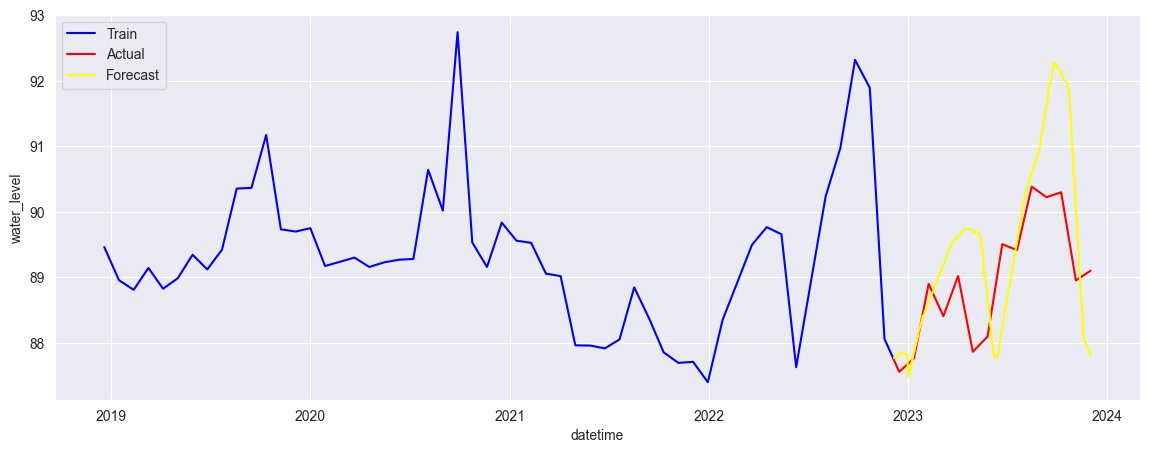

In [30]:
plt.figure(figsize=(14,5))
sns.lineplot(x = df['datetime'].iloc[:split_idx], y = y_train, color = 'blue', label = 'Train')
sns.lineplot(x = df['datetime'].iloc[split_idx:], y = y_test, color = 'red', label = 'Actual')
sns.lineplot(x = df['datetime'].iloc[split_idx:], y = test_pred, color = 'yellow', label = 'Forecast')
plt.title('')
plt.show()


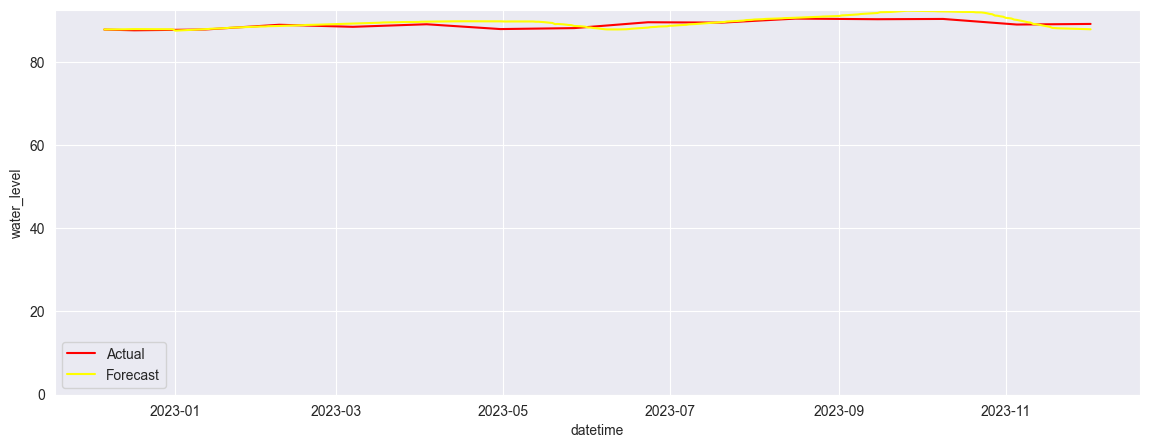

In [31]:
plt.figure(figsize=(14,5))
#sns.lineplot(x = df['datetime'].iloc[:split_idx], y = y_train, color = 'blue', label = 'Train')
sns.lineplot(x = df['datetime'].iloc[split_idx:], y = y_test, color = 'red', label = 'Actual')
sns.lineplot(x = df['datetime'].iloc[split_idx:], y = test_pred, color = 'yellow', label = 'Forecast')
plt.title('')
plt.ylim(0)
plt.show()

In [32]:
forecast_start_date = df['datetime'].max()
forecast_end_date = forecast_start_date + pd.Timedelta(days = 365)
forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='D')
print(f"Forecasting from {forecast_dates.min()} to {forecast_dates.max()} ({len(forecast_dates)} days).")

Forecasting from 2023-12-02 00:00:00 to 2024-12-01 00:00:00 (366 days).


In [33]:
# Training
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

#Accuracy
train_accuracy = model.score(X, y)

#Prediction


train_accuracy

0.9997497295509337

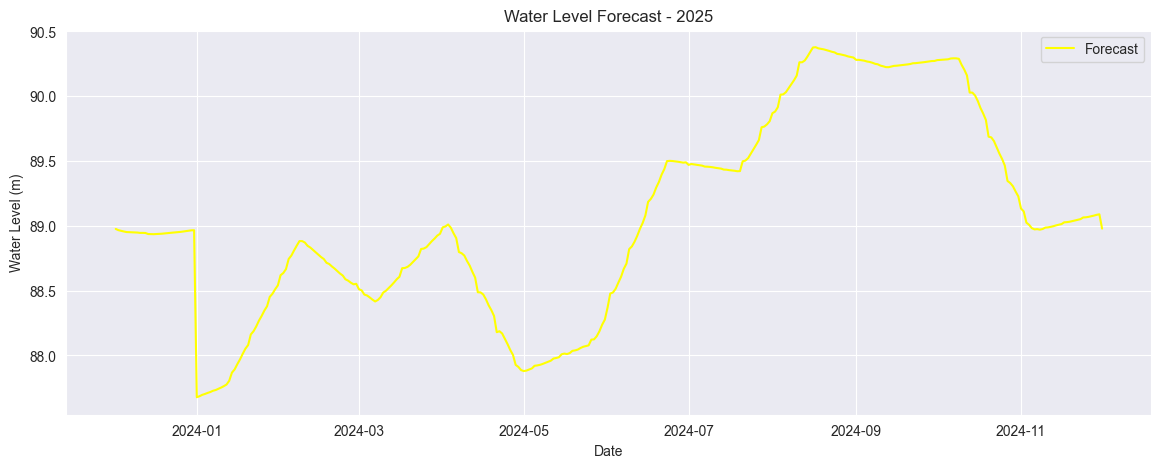

In [34]:
df = pd.DataFrame(forecast_dates)
df.columns = ['datetime']
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day_of_year'] = df['datetime'].dt.dayofyear
df['week_of_year'] = df.day_of_year//7 + 1
df = df.drop(['datetime', 'day_of_year'], axis = 1)
prediction = model.predict(df)

plt.figure(figsize=(14,5))
sns.lineplot(y = prediction, x = forecast_dates, color = 'yellow', label = 'Forecast')
plt.title('Water Level Forecast - 2025')
plt.xlabel('Date')
plt.ylabel('Water Level (m)')
plt.show()



In [43]:
datasets = []
for _, _, filenames in os.walk('Daily River levels'):
    datasets.append(filenames)

datasets[0]

['dahiti_11447_daily_2025-06-23.csv',
 'dahiti_11715_daily_2025-06-23.csv',
 'dahiti_12130_daily_2025-06-23.csv',
 'dahiti_12139_daily_2025-06-23.csv',
 'dahiti_12141_daily_2025-06-23.csv',
 'dahiti_12316_daily_2025-06-23.csv',
 'dahiti_13109_daily_2025-06-23.csv',
 'dahiti_13110_daily_2025-06-23.csv',
 'dahiti_13111_daily_2025-06-23.csv',
 'dahiti_13244_daily_2025-06-23.csv',
 'dahiti_137_daily_2025-06-23.csv',
 'dahiti_14200_daily_2025-06-23.csv',
 'dahiti_14694_daily_2025-06-23.csv',
 'dahiti_15354_daily_2025-06-23.csv',
 'dahiti_15714_daily_2025-06-23.csv',
 'dahiti_15715_daily_2025-06-23.csv',
 'dahiti_15928_daily_2025-06-23.csv',
 'dahiti_16329_daily_2025-06-23.csv',
 'dahiti_16482_daily_2025-06-23.csv',
 'dahiti_16697_daily_2025-06-23.csv',
 'dahiti_18042_daily_2025-06-23.csv']

In [46]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

forecast_df = pd.DataFrame()
for dataset in datasets[0]:
    dataset_path = f'Daily River levels/{dataset}'
    data = pd.read_csv(dataset_path)

    try:
        data['datetime'] = pd.to_datetime(data['datetime'])
    except:
        data['datetime'] = pd.to_datetime(data['datetime'], format = "%d/%m/%Y")

    df = data[(data['datetime'] >= '2018-01-01') &(data['datetime'] <= '2024-12-31')] # 2018 t0 2024 data
    df = df.reset_index().drop('index', axis = 1)

    # Preprocessing
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['week_of_year'] = df.day_of_year//7 + 1

    # Scaler
    scaler = MinMaxScaler()
    df['water_level'] = scaler.fit_transform(df['water_level'].values.reshape(-1,1)) * 10

    # Splitting
    #split_date = '2024-01-01'
    split_idx = int(0.8*len(X))          #len(df[df['datetime'] <= split_date])

    X = df.drop(['datetime', 'day_of_year', 'water_level'], axis = 1)
    y = df['water_level']


    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Training
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    #Accuracy
    #train_accuracy = model.score(X_train, y_train)
    #test_accuracy = model.score(X_test, y_test)

    #accuracies = [train_accuracy, test_accuracy]


    # Forecasting
    forecast_start_date = df['datetime'].max()
    forecast_end_date = forecast_start_date + pd.Timedelta(days = 365)
    forecast_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='D')
    #print(f"Forecasting from {forecast_dates.min()} to {forecast_dates.max()} ({len(forecast_dates)} days).")

    df1 = pd.DataFrame(forecast_dates)
    df1.columns = ['datetime']
    df1['day'] = df1['datetime'].dt.day
    df1['month'] = df1['datetime'].dt.month
    df1['year'] = df1['datetime'].dt.year
    df1['day_of_year'] = df1['datetime'].dt.dayofyear
    df1['week_of_year'] = df1.day_of_year//7 + 1
    df1 = df1.drop(['datetime', 'day_of_year'], axis = 1)
    prediction = model.predict(df1)

    #plt.figure(figsize=(14,5))
    #sns.lineplot(y = prediction, x = forecast_dates, color = 'red', label = 'Forecast')
    #plt.title('Water Level Forecast - 2025')
    #plt.xlabel('Date')
    #plt.ylabel('Water Level (m)')
    #plt.show()


    actual = df[df['datetime'].dt.year ==  2024]
    #actual['water_level'] = scaler.transform(actual['water_level'].values.reshape(-1,1)) * 10
    actual['type'] = 'Actual'

    pred = pd.DataFrame(forecast_dates)
    pred.columns = ['datetime']
    pred['water_level'] = prediction
    pred['type'] = 'Forecasted'

    full_df = pd.concat([actual, pred], axis = 0)

    try:
        full_df['id'] = dataset_path.split('_')[1]
    except:
        full_df['id'] = dataset_path.split('_')[1]

    full_df = full_df[['id','datetime', 'water_level', 'type']]

    forecast_df = pd.concat([forecast_df, full_df], axis = 0)




In [49]:
forecast_df

,id,datetime,water_level,type
2191,11447,2024-01-01,6.950196,Actual
2192,11447,2024-01-02,6.912282,Actual
2193,11447,2024-01-03,6.851202,Actual
2194,11447,2024-01-04,6.790121,Actual
2195,11447,2024-01-05,6.729040,Actual
...,...,...,...,...
361,18042,2025-12-27,1.407297,Forecasted
362,18042,2025-12-28,1.449635,Forecasted
363,18042,2025-12-29,1.484892,Forecasted
364,18042,2025-12-30,1.531193,Forecasted


In [48]:
forecast_df.to_csv('River levels Scaled Forecast Updated.csv', index = False)